In [3]:
from dotenv import load_dotenv

load_dotenv()

from typing import Annotated
from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [4]:
llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

class State(TypedDict) :
    messages : Annotated[list, add_messages]

def chatbot(state : State) -> State:
    return { "messages": [llm.invoke(state["messages"])] }


builder = StateGraph(State)

builder.add_node("create_chatbot", chatbot)

builder.add_edge(START, "create_chatbot")
builder.add_edge("create_chatbot", END)

graph = builder.compile()

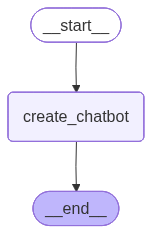

In [5]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
message = {
    "role" : "user",
    "content" : "who is B-rad from clash royale content creator?"
}

response = graph.invoke({"messages" : [message]})

response["messages"]

[HumanMessage(content='who is B-rad from clash royale content creator?', additional_kwargs={}, response_metadata={}, id='16ac4b85-8e13-43df-9079-d85173535387'),
 AIMessage(content="B-rad is a popular content creator who focuses on the mobile game **Clash Royale**.\n\nHe's known for:\n\n*   **His energetic and often humorous personality:** He has a very distinct and enthusiastic style of commentary.\n*   **His gameplay and deck guides:** He showcases various decks, offers tips and strategies for climbing the ladder, and often explains his thought process.\n*   **His involvement in the Clash Royale community:** He's a well-established figure within the game's content creation scene.\n*   **His YouTube channel:** This is where he primarily shares his Clash Royale content, including gameplay, challenges, and updates.\n\nIf you're looking for Clash Royale content with a fun and engaging personality, B-rad is definitely a creator to check out!", additional_kwargs={}, response_metadata={'fini

In [8]:
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"exit", "quit"}:
        break
    if state is None:
        state : State = {
            "messages": [{ "role": "user", "content": in_message }]
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})
    
    state = graph.invoke(state)

    print("Bot: ", state["messages"][-1].content)

Bot:  Neil Armstrong
Bot:  1969
Bot:  Apollo 11
Bot:  NASA
Bot:  That's a really interesting question, and the answer is a bit complex because "journey" can be interpreted in a few ways.

If you're asking about the total number of **distinct spacecraft that NASA has launched into space for any purpose (missions to planets, satellites, space stations, etc.)**, it's a very large number, well into the **thousands**. NASA has been launching missions for over 60 years, and many of those have involved multiple spacecraft.

However, if you're thinking more specifically about **manned missions** or missions that have gone beyond Earth's orbit, the number is much smaller.

To give you a precise number would require a very specific definition of "spaceship" and "journey" and a deep dive into NASA's historical launch manifest, which is constantly being updated.

**Could you clarify what you mean by "spaceships" and "journey" so I can give you a more tailored answer?** For example, are you interes